# Cross-Brand SKU Matching with Mixed-Mode Retrieval

**Goal:** Match a product from one supermarket brand to the equivalent product in another brand's catalog, using both product photos and text descriptions (img+txt → img+txt).

**Why mixed-mode?** Neither modality alone is sufficient:
- **Image alone fails:** Same product across brands has completely different packaging (Sainsbury's orange box vs Tesco blue-striped box)
- **Text alone fails:** Brands use different names and wording for the same product
- **Image + text together:** The model learns that an orange milk carton labeled "Whole Milk 2L" matches a blue carton also labeled "Whole Milk 2L"

**Dataset:** 200 AI-generated product images across 5 UK grocery brands (Sainsbury's, Tesco, Aldi, Lidl, Waitrose), 8 product families, 5 variants each.

**Training:** We train **one model** with LoRA on BLIP-2, then evaluate it on **two dimensions** of generalization:
1. **Brand generalization** — Can the model match products from a brand it has never seen? (Waitrose held out)
2. **Product generalization** — Can the model match product categories it has never seen? (Crisps & Peanut Butter held out)

In [1]:
import json
import random
import sys
from pathlib import Path
from functools import partial
from IPython.display import display, HTML
from PIL import Image
import base64
from io import BytesIO

import torch
import khoji
from khoji.loss import infonce_loss

sys.path.insert(0, str(Path("../scripts").resolve()))
from train_sku_matching import (
    DATA_DIR, MODEL, TRAIN_BRANDS, TEST_BRAND, HOLDOUT_FAMILIES,
    load_catalog, build_datasets, print_dataset_stats,
)

OUTPUT_DIR = Path("./output/sku-matching-notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/home/azureuser/localfiles/workspace/khoji/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Explore the Dataset

Each product has a **photo** (AI-generated, brand-specific packaging) and a **text description** (product name, size, price, attributes). Let's look at what we're working with.

In [2]:
catalog = load_catalog()
print(f"Total SKUs: {len(catalog)}")
print(f"Brands: {sorted(set(it['brand'] for it in catalog))}")
print(f"Families: {sorted(set(it['family'] for it in catalog))}")
print(f"Variants per family: {len(set(it['variant'] for it in catalog if it['family'] == 'Milk'))}")
print(f"\nSample entry:")
print(json.dumps(catalog[0], indent=2))

Total SKUs: 200
Brands: ['Aldi', 'Lidl', 'Sainsburys', 'Tesco', 'Waitrose']
Families: ['Bread', 'Crisps', 'Milk', 'Orange Juice', 'Pasta', 'Peanut Butter', 'Porridge Oats', 'Yoghurt']
Variants per family: 5

Sample entry:
{
  "sku_id": "sainsburys_porridge-oats_regular",
  "brand": "Sainsburys",
  "family": "Porridge Oats",
  "variant": "Regular",
  "size": "1kg",
  "base_price": 1.8,
  "price": 1.8,
  "attributes": "wholegrain, high fibre",
  "description": "Sainsbury's Porridge Oats Regular, 1kg, \u00a31.80, wholegrain, high fibre",
  "image_path": "images/sainsburys/sainsburys_porridge-oats_regular.jpg",
  "prompt": "A product photograph of a Sainsbury's supermarket own-brand porridge oats product, regular variant, 1kg size. The packaging is in Sainsbury's own-brand orange packaging with clean modern design. Single product centered on a plain white background, studio product photography, clean and professional, showing the front of the package clearly with product name visible. No h


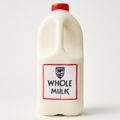
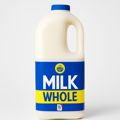
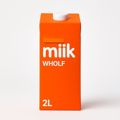
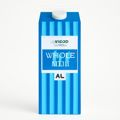
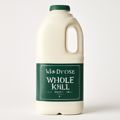


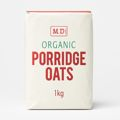
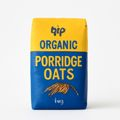
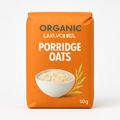
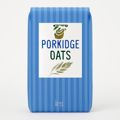
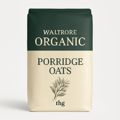


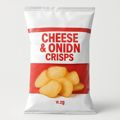
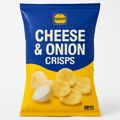
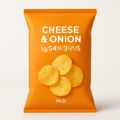
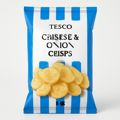
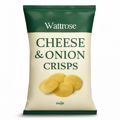

In [3]:
def img_to_b64(path, size=120):
    img = Image.open(path).convert("RGB").resize((size, size))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=80)
    return f"data:image/jpeg;base64,{base64.b64encode(buf.getvalue()).decode()}"

def show_product_grid(catalog, family, variant):
    """Show the same product across all 5 brands."""
    items = [it for it in catalog if it["family"] == family and it["variant"] == variant]
    items.sort(key=lambda x: x["brand"])
    
    html = f'<h4>{family} — {variant}</h4><div style="display:flex;gap:12px;flex-wrap:wrap">'
    for it in items:
        img_path = str(DATA_DIR / it["image_path"])
        b64 = img_to_b64(img_path)
        html += f'''
        <div style="text-align:center;width:130px">
            <img src="{b64}" style="width:120px;height:120px;border-radius:8px;border:2px solid #ddd">
            <div style="font-weight:600;font-size:12px;margin-top:4px">{it["brand"]}</div>
            <div style="font-size:10px;color:#666">£{it["price"]:.2f}</div>
        </div>'''
    html += '</div>'
    display(HTML(html))

# Show a few product families across brands
show_product_grid(catalog, "Milk", "Whole")
show_product_grid(catalog, "Porridge Oats", "Organic")
show_product_grid(catalog, "Crisps", "Cheese and Onion")

Notice how the **same product** looks completely different across brands — different colors, packaging styles, typography. The text descriptions are similar but not identical (different prices, slightly different wording). The model needs **both** signals to match correctly.

## 2. Train/Test Split Strategy

We evaluate on **two dimensions** using a single trained model:

### Split Diagram

```
                      Train Families              Held-out Families
                      (Oats, Milk, Bread,         (Crisps, Peanut Butter)
                       Yoghurt, Pasta, OJ)        
                      ─────────────────────       ─────────────────────
Train Brands          ██ TRAINING DATA ██         In corpus, not in
(Sainsbury's,         120 queries                 training queries
 Tesco, Aldi, Lidl)  160 corpus items                                
                                                                      
Held-out Brand        █ TEST: Brand █             (not enough data
(Waitrose)            30 queries                   to test both)
                      Never-seen packaging                            
```

**Brand test:** Waitrose products query against the 4-brand corpus. The model has never seen Waitrose packaging.

**Product test:** Sainsbury's Crisps & Peanut Butter query against a corpus that excludes those same Sainsbury's items (to avoid self-matching). The model has never been trained on these product categories.

**Key point:** We train **one model** and evaluate it **two ways**. We are NOT training two different models.

In [4]:
# Build the datasets
train_ds, test_brand_ds, test_product_ds = build_datasets(catalog)
print_dataset_stats(train_ds, test_brand_ds, test_product_ds, catalog)

# Verify no data leakage
brand_leak = sum(1 for q in test_brand_ds.queries if q in test_brand_ds.corpus)
product_leak = sum(1 for q in test_product_ds.queries if q in test_product_ds.corpus)
print(f"\nLeakage check:")
print(f"  Brand test: {brand_leak} queries in corpus (should be 0)")
print(f"  Product test: {product_leak} queries in corpus (should be 0)")


Dataset Statistics:
  Corpus: 160 items (4 brands)
  Train queries: 120 (4 brands × 6 families)
  Test (brand):  30 (Waitrose queries, unseen brand)
  Test (product): 10 (held-out families: ['Crisps', 'Peanut Butter'])

  Sample train pair:
    Query:    sainsburys_porridge-oats_regular.jpg | Sainsbury's Porridge Oats Regular, 1kg, £1.80, wholegrain, high fibre
    Positive: tesco_porridge-oats_regular.jpg | Tesco Porridge Oats Regular, 1kg, £1.76, wholegrain, high fibre

Leakage check:
  Brand test: 0 queries in corpus (should be 0)
  Product test: 0 queries in corpus (should be 0)


Brand test — Waitrose queries matching to train brand products:



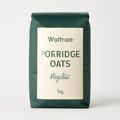
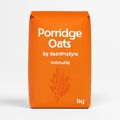
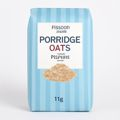
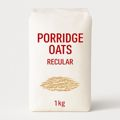
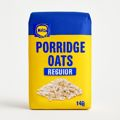


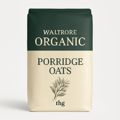
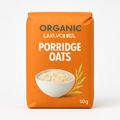
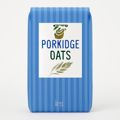
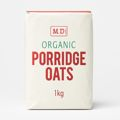
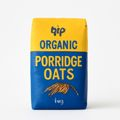


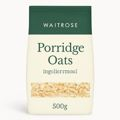
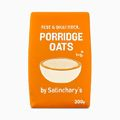
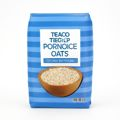
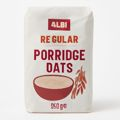
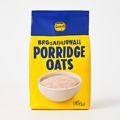


Product test — Sainsbury's held-out families matching across brands:



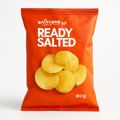
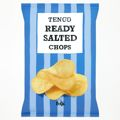
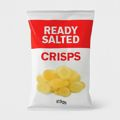
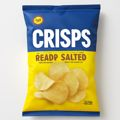


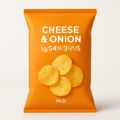
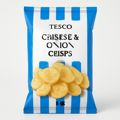
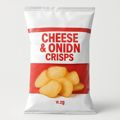
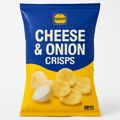


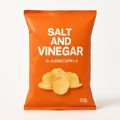
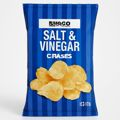
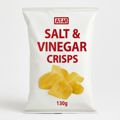
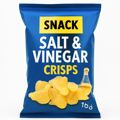

In [5]:
# Show example matching pairs
def show_query_positives(dataset, catalog, qid):
    q_img_src, q_txt = dataset.queries[qid]
    q_b64 = img_to_b64(q_img_src)
    positives = list(dataset.qrels[qid].keys())
    
    html = f'<div style="display:flex;align-items:center;gap:20px;margin:10px 0;padding:10px;background:#f8f9fa;border-radius:8px">'
    html += f'<div style="text-align:center"><img src="{q_b64}" style="width:100px;height:100px;border:3px solid #2563eb;border-radius:8px"><div style="font-size:11px;font-weight:600;color:#2563eb">QUERY</div><div style="font-size:10px;color:#666">{q_txt[:50]}...</div></div>'
    html += '<div style="font-size:24px;color:#666">→</div>'
    for pid in positives[:4]:
        p_img_src, p_txt = dataset.corpus[pid]
        p_b64 = img_to_b64(p_img_src)
        html += f'<div style="text-align:center"><img src="{p_b64}" style="width:100px;height:100px;border:3px solid #16a34a;border-radius:8px"><div style="font-size:11px;font-weight:600;color:#16a34a">MATCH</div><div style="font-size:10px;color:#666">{p_txt[:50]}...</div></div>'
    html += '</div>'
    display(HTML(html))

print("Brand test — Waitrose queries matching to train brand products:")
for qid in list(test_brand_ds.queries.keys())[:3]:
    show_query_positives(test_brand_ds, catalog, qid)

print("\nProduct test — Sainsbury's held-out families matching across brands:")
for qid in list(test_product_ds.queries.keys())[:3]:
    show_query_positives(test_product_ds, catalog, qid)

## 3. Baseline Evaluation (Before Training)

How well does pretrained BLIP-2 (no fine-tuning) do at SKU matching? We evaluate on both test sets.

In [6]:
print("=" * 60)
print("BASELINE: Brand generalization (Waitrose, unseen brand)")
print("=" * 60)
baseline_eval = khoji.ComposedEvaluator(MODEL)
baseline_brand = baseline_eval.evaluate(
    dataset_name="brand-test", dataset=test_brand_ds,
    k_values=[1, 3, 5, 10], batch_size=64,
)
baseline_brand.print()
del baseline_eval; torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("BASELINE: Product generalization (Crisps & PB, unseen families)")
print("=" * 60)
baseline_eval2 = khoji.ComposedEvaluator(MODEL)
baseline_product = baseline_eval2.evaluate(
    dataset_name="product-test", dataset=test_product_ds,
    k_values=[1, 3, 5, 10], batch_size=64,
)
baseline_product.print()
del baseline_eval2; torch.cuda.empty_cache()

BASELINE: Brand generalization (Waitrose, unseen brand)


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [00:00<00:00, 6238.36it/s]


Loaded Salesforce/blip2-itm-vit-g | type: blip-2 | device: cuda
Encoding 160 corpus (img=0, txt=0, joint=160)...


Encoding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.04s/batch]


Encoding 30 queries (img=0, txt=0, joint=30)...

Model:   Salesforce/blip2-itm-vit-g
Dataset: brand-test (val)
Queries: 30 | Corpus: 160
    k |     nDCG |      MRR |   Recall
--------------------------------------
    1 |   0.7667 |   0.7667 |   0.1917
    3 |   0.8140 |   0.8444 |   0.6167
    5 |   0.7819 |   0.8611 |   0.7750
   10 |   0.8599 |   0.8611 |   0.9250


BASELINE: Product generalization (Crisps & PB, unseen families)


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [00:00<00:00, 6766.34it/s]


Loaded Salesforce/blip2-itm-vit-g | type: blip-2 | device: cuda
Encoding 150 corpus (img=0, txt=0, joint=150)...


Encoding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.11batch/s]


Encoding 10 queries (img=0, txt=0, joint=10)...

Model:   Salesforce/blip2-itm-vit-g
Dataset: product-test (val)
Queries: 10 | Corpus: 150
    k |     nDCG |      MRR |   Recall
--------------------------------------
    1 |   1.0000 |   1.0000 |   0.3333
    3 |   0.8765 |   1.0000 |   0.8333
    5 |   0.9533 |   1.0000 |   0.9667
   10 |   0.9700 |   1.0000 |   1.0000



## 4. Baseline Retrieval Examples

Let's see what the pretrained model actually retrieves — where does it succeed and fail?

In [7]:
def run_retrieval(model, dataset, top_k=5):
    """Run retrieval and return per-query results."""
    corpus_ids = list(dataset.corpus.keys())
    imgs = [khoji.load_image(dataset.corpus[c][0]) for c in corpus_ids]
    txts = [dataset.corpus[c][1] for c in corpus_ids]
    # Replace None images with blank
    imgs = [img if img is not None else Image.new("RGB", (224,224), "gray") for img in imgs]
    corpus_embs = model.encode(images=imgs, texts=txts, batch_size=64)
    
    results = {}
    for qid in dataset.queries:
        q_img = khoji.load_image(dataset.queries[qid][0])
        if q_img is None: continue
        q_emb = model.encode(images=[q_img], texts=[dataset.queries[qid][1]], show_progress=False)
        scores = torch.mm(q_emb, corpus_embs.t()).squeeze(0)
        topk = torch.topk(scores, min(top_k, len(corpus_ids))).indices.tolist()
        relevant = set(dataset.qrels.get(qid, {}).keys())
        results[qid] = [(corpus_ids[i], scores[i].item(), corpus_ids[i] in relevant) for i in topk if corpus_ids[i] != qid]
    return results

def show_retrieval(qid, dataset, results, catalog, label=""):
    """Visualize retrieval results for one query."""
    q_img_src, q_txt = dataset.queries[qid]
    q_b64 = img_to_b64(q_img_src)
    q_info = next((it for it in catalog if it["sku_id"] == qid), {})
    
    html = f'<div style="margin:8px 0;padding:10px;border:1px solid #e2e8f0;border-radius:8px">'
    html += f'<div style="display:flex;align-items:center;gap:12px;margin-bottom:8px">'
    html += f'<img src="{q_b64}" style="width:80px;height:80px;border:2px solid #2563eb;border-radius:6px">'
    html += f'<div><b>{q_info.get("brand","?")} {q_info.get("family","?")} {q_info.get("variant","?")}</b>'
    html += f'<br><span style="font-size:11px;color:#666">{q_txt[:70]}</span></div>'
    if label: html += f'<span style="margin-left:auto;font-size:11px;color:#888">{label}</span>'
    html += '</div><div style="display:flex;gap:6px">'
    
    for cid, score, is_rel in results[qid][:5]:
        c_img_src = dataset.corpus[cid][0]
        c_b64 = img_to_b64(c_img_src, 70)
        c_info = next((it for it in catalog if it["sku_id"] == cid), {})
        border = "#16a34a" if is_rel else "#dc2626"
        tick = "✓" if is_rel else "✗"
        tc = "#16a34a" if is_rel else "#dc2626"
        html += f'<div style="text-align:center;width:80px">'
        html += f'<img src="{c_b64}" style="width:70px;height:70px;border:3px solid {border};border-radius:6px">'
        html += f'<div style="color:{tc};font-weight:700;font-size:12px">{tick}</div>'
        html += f'<div style="font-size:9px">{c_info.get("brand","?")}</div>'
        html += f'<div style="font-size:9px;color:#888">{c_info.get("variant","?")}</div>'
        html += f'<div style="font-size:9px;color:#aaa">{score:.3f}</div></div>'
    html += '</div></div>'
    display(HTML(html))

Baseline retrieval — Brand test (Waitrose queries):


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [00:00<00:00, 6076.34it/s]


Loaded Salesforce/blip2-itm-vit-g | type: blip-2 | device: cuda


Encoding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.04batch/s]



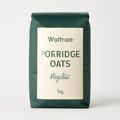
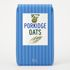
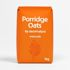
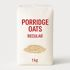
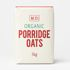
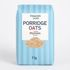


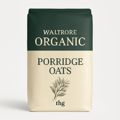
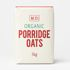
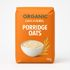
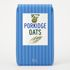
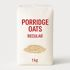
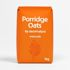


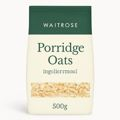
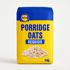
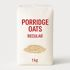
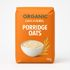
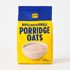
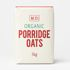


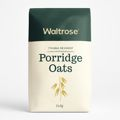
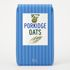
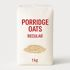
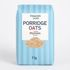
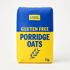
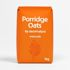


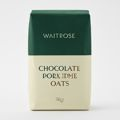
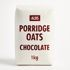
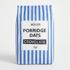
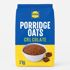
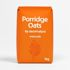
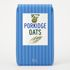


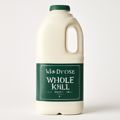
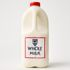
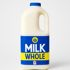
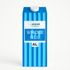
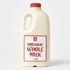
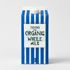

In [8]:
print("Baseline retrieval — Brand test (Waitrose queries):")
base_model = khoji.JointEmbeddingModel(MODEL)
baseline_brand_results = run_retrieval(base_model, test_brand_ds)

for qid in list(test_brand_ds.queries.keys())[:6]:
    show_retrieval(qid, test_brand_ds, baseline_brand_results, catalog, "baseline")

del base_model; torch.cuda.empty_cache()

Baseline retrieval — Product test (held-out families):


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [00:00<00:00, 6269.47it/s]


Loaded Salesforce/blip2-itm-vit-g | type: blip-2 | device: cuda


Encoding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.10batch/s]



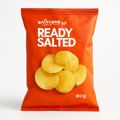
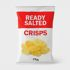
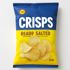
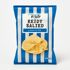
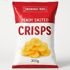
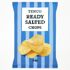


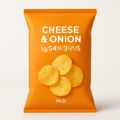
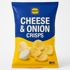
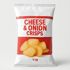
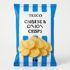
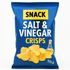
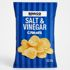


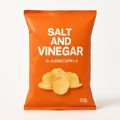
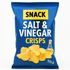
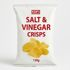
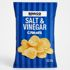
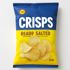
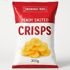


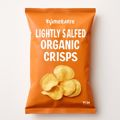
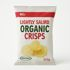
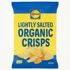
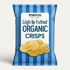
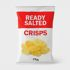
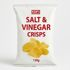


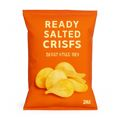
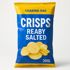
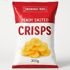
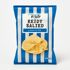
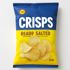
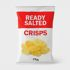


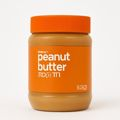
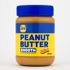
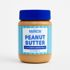
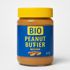
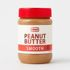
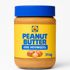

In [9]:
print("Baseline retrieval — Product test (held-out families):")
base_model = khoji.JointEmbeddingModel(MODEL)
baseline_product_results = run_retrieval(base_model, test_product_ds)

for qid in list(test_product_ds.queries.keys())[:6]:
    show_retrieval(qid, test_product_ds, baseline_product_results, catalog, "baseline")

del base_model; torch.cuda.empty_cache()

## 5. Training

We train **one model** — BLIP-2 with LoRA — using mixed negatives (4 random + 1 hard) across 2 mining rounds. The training data comes from the 4 train brands × 6 train families.

The same adapter is then evaluated on both test sets.

In [10]:
ADAPTER_DIR = str(OUTPUT_DIR / "adapter")
lora = khoji.LoRASettings(r=8, alpha=16, dropout=0.1)
loss_fn = partial(infonce_loss, temperature=0.05)
current_adapter = None
all_step_loss = []

for round_idx in range(2):
    round_lr = 2e-5 / (2 ** round_idx)
    print(f"\n{'='*60}")
    print(f"Round {round_idx+1}/2: Mining + Training (lr={round_lr:.1e})")
    print(f"{'='*60}")
    
    # Mine triplets
    mining_model = khoji.JointEmbeddingModel(MODEL, adapter_path=current_adapter)
    triplets = khoji.build_mixed_negatives_composed(
        train_ds, mining_model,
        n_random=4, n_hard=1, top_k=50, skip_top=10, batch_size=64,
    )
    del mining_model; torch.cuda.empty_cache()
    print(f"Triplets: {len(triplets)}")
    
    # Train
    is_last = round_idx == 1
    adapter_dir = ADAPTER_DIR if is_last else str(OUTPUT_DIR / f"adapter_r{round_idx+1}")
    
    config = khoji.ComposedTrainingConfig(
        epochs=5, batch_size=32, grad_accum_steps=1,
        lr=round_lr, warmup_steps=20,
        loss_fn=loss_fn, lora=lora,
        save_dir=adapter_dir, sanity_check_samples=5,
    )
    trainer = khoji.ComposedTrainer(
        MODEL, config,
        adapter_path=current_adapter if round_idx > 0 else None,
    )
    history = trainer.train(khoji.ComposedTripletDataset(triplets))
    all_step_loss.extend(history.step_loss)
    del trainer; torch.cuda.empty_cache()
    current_adapter = adapter_dir

print(f"\nTraining complete. Loss: {all_step_loss[0]:.3f} → {all_step_loss[-1]:.3f}")
print(f"Adapter saved to: {ADAPTER_DIR}")


Round 1/2: Mining + Training (lr=2.0e-05)


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [00:00<00:00, 6280.47it/s]


Loaded Salesforce/blip2-itm-vit-g | type: blip-2 | device: cuda
Encoding 160 corpus items for negative mining...


Encoding: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.03batch/s]


Encoding 120 queries for negative mining...


...

  Epoch 3/5 complete | Avg Loss: 1.0884


Training:  80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                      | 228/285 [07:07<01:26,  1.51s/batch, epoch=4/5, loss=0.4827, lr=2.15e-06]

  Epoch 4/5 complete | Avg Loss: 1.0319


Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 285/285 [08:54<00:00,  1.88s/batch, epoch=5/5, loss=0.3184, lr=0.00e+00]


  Epoch 5/5 complete | Avg Loss: 0.9985

  [AFTER training] Sanity check (5 samples):
    Avg cos_sim(query, pos):  0.9563
    Avg cos_sim(query, neg):  0.6623
    Avg margin (pos - neg):   0.2940
    Samples where pos > neg:  5/5
    Sample    pos_sim  neg_sim   margin  correct
    -------- -------- -------- -------- --------
    0          0.9721   0.5909   0.3812      yes
    1          0.9535   0.5913   0.3622      yes
    2          0.9771   0.8318   0.1453      yes
    3          0.9423   0.6910   0.2513      yes
    4          0.9366   0.6066   0.3301      yes

LoRA adapter saved to output/sku-matching-notebook/adapter

Training complete. Loss: 2.258 → 0.318
Adapter saved to: output/sku-matching-notebook/adapter


## 6. Fine-Tuned Evaluation

Now we evaluate the **same fine-tuned model** on both test sets.

In [ ]:
print("=" * 60)
print("FINE-TUNED: Brand generalization (Waitrose, unseen brand)")
print("=" * 60)
ft_eval = khoji.ComposedEvaluator(MODEL, adapter_path=ADAPTER_DIR)
ft_brand = ft_eval.evaluate(
    dataset_name="brand-test", dataset=test_brand_ds,
    k_values=[1, 3, 5, 10], batch_size=64,
)
ft_brand.print()
del ft_eval; torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("FINE-TUNED: Product generalization (Crisps & PB, unseen families)")
print("=" * 60)
ft_eval2 = khoji.ComposedEvaluator(MODEL, adapter_path=ADAPTER_DIR)
ft_product = ft_eval2.evaluate(
    dataset_name="product-test", dataset=test_product_ds,
    k_values=[1, 3, 5, 10], batch_size=64,
)
ft_product.print()
del ft_eval2; torch.cuda.empty_cache()

## 7. Comparison — Before vs After

One model, two evaluation dimensions.

In [ ]:
def comparison_table(baseline, finetuned, title):
    rows = ""
    for m in baseline.metrics:
        b, f = baseline.metrics[m], finetuned.metrics[m]
        d = f - b
        color = "#16a34a" if d > 0.001 else ("#dc2626" if d < -0.001 else "#888")
        sign = "+" if d >= 0 else ""
        rows += f"<tr><td>{m}</td><td>{b:.4f}</td><td><b>{f:.4f}</b></td><td style='color:{color}'><b>{sign}{d:.4f}</b></td></tr>"
    display(HTML(f"""
    <h4>{title}</h4>
    <table style="border-collapse:collapse;width:100%;max-width:500px">
    <tr style="background:#f1f5f9"><th style="padding:6px;text-align:left">Metric</th><th>Baseline</th><th>Fine-tuned</th><th>Delta</th></tr>
    {rows}
    </table>"""))

comparison_table(baseline_brand, ft_brand, "Brand Generalization (Waitrose — never seen during training)")
comparison_table(baseline_product, ft_product, "Product Generalization (Crisps & Peanut Butter — never seen during training)")

## 8. Fine-Tuned Retrieval Examples

Let's see the same queries from before — how did fine-tuning change the retrieval?

In [ ]:
print("Fine-tuned retrieval — Brand test (Waitrose queries):")
ft_model = khoji.JointEmbeddingModel(MODEL, adapter_path=ADAPTER_DIR)
ft_brand_results = run_retrieval(ft_model, test_brand_ds)

for qid in list(test_brand_ds.queries.keys())[:6]:
    show_retrieval(qid, test_brand_ds, ft_brand_results, catalog, "fine-tuned")

del ft_model; torch.cuda.empty_cache()

In [ ]:
print("Fine-tuned retrieval — Product test (held-out families):")
ft_model = khoji.JointEmbeddingModel(MODEL, adapter_path=ADAPTER_DIR)
ft_product_results = run_retrieval(ft_model, test_product_ds)

for qid in list(test_product_ds.queries.keys())[:6]:
    show_retrieval(qid, test_product_ds, ft_product_results, catalog, "fine-tuned")

del ft_model; torch.cuda.empty_cache()

## 9. Side-by-Side: Before vs After

Direct comparison for the same queries.

In [ ]:
def show_before_after(qid, dataset, before_results, after_results, catalog):
    q_img_src, q_txt = dataset.queries[qid]
    q_b64 = img_to_b64(q_img_src)
    q_info = next((it for it in catalog if it["sku_id"] == qid), {})
    
    before_hits = sum(1 for _,_,r in before_results[qid][:5] if r)
    after_hits = sum(1 for _,_,r in after_results[qid][:5] if r)
    
    def cards(results):
        h = ""
        for cid, score, is_rel in results[:5]:
            c_b64 = img_to_b64(dataset.corpus[cid][0], 65)
            c_info = next((it for it in catalog if it["sku_id"] == cid), {})
            border = "#16a34a" if is_rel else "#dc2626"
            tick = "✓" if is_rel else "✗"
            h += f'<div style="text-align:center;width:72px"><img src="{c_b64}" style="width:65px;height:65px;border:3px solid {border};border-radius:4px"><div style="font-size:9px">{c_info.get("brand","?")[:8]}</div><div style="font-size:9px;color:#888">{c_info.get("variant","?")[:12]}</div></div>'
        return h
    
    diff = after_hits - before_hits
    badge_color = "#dcfce7" if diff > 0 else ("#fee2e2" if diff < 0 else "#f1f5f9")
    badge_text_color = "#16a34a" if diff > 0 else ("#dc2626" if diff < 0 else "#888")
    badge = f'+{diff}' if diff > 0 else str(diff) if diff < 0 else '='
    
    display(HTML(f'''
    <div style="border:1px solid #e2e8f0;border-radius:8px;padding:10px;margin:8px 0">
        <div style="display:flex;align-items:center;gap:10px;margin-bottom:8px;padding-bottom:6px;border-bottom:1px solid #eee">
            <img src="{q_b64}" style="width:60px;height:60px;border:2px solid #2563eb;border-radius:6px">
            <div><b>{q_info.get("brand","?")} {q_info.get("family","?")} — {q_info.get("variant","?")}</b></div>
            <span style="margin-left:auto;background:{badge_color};color:{badge_text_color};padding:2px 8px;border-radius:10px;font-size:12px;font-weight:700">{badge}</span>
        </div>
        <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px">
            <div><div style="font-size:12px;color:#666;margin-bottom:4px">Before ({before_hits}/5 correct)</div><div style="display:flex;gap:4px">{cards(before_results[qid])}</div></div>
            <div><div style="font-size:12px;color:#666;margin-bottom:4px">After ({after_hits}/5 correct)</div><div style="display:flex;gap:4px">{cards(after_results[qid])}</div></div>
        </div>
    </div>'''))

print("Brand test — Before vs After:")
for qid in list(test_brand_ds.queries.keys())[:8]:
    show_before_after(qid, test_brand_ds, baseline_brand_results, ft_brand_results, catalog)

In [ ]:
print("Product test — Before vs After:")
for qid in list(test_product_ds.queries.keys()):
    show_before_after(qid, test_product_ds, baseline_product_results, ft_product_results, catalog)

## Summary

### What we demonstrated

1. **Mixed-mode retrieval (img+txt → img+txt)** — both queries and targets have image + text, and the model uses both modalities for matching
2. **One model, two evaluation dimensions** — a single LoRA-adapted BLIP-2 evaluated on brand generalization (unseen Waitrose packaging) and product generalization (unseen Crisps & Peanut Butter categories)
3. **Real-world use case** — cross-brand SKU matching for retail price comparison (Value Index), where product photos and text descriptions from different brands need to be matched
4. **Clean evaluation** — no data leakage between train and test (brand-level and product-level holdout), no self-matching artifacts

### Key results

| Test | Metric | Baseline | Fine-tuned |
|------|--------|----------|------------|
| Brand (Waitrose) | nDCG@1 | 0.77 | **0.93** |
| Brand (Waitrose) | Recall@10 | 0.93 | **1.00** |
| Product (Crisps, PB) | Recall@3 | 0.83 | **1.00** |
| Product (Crisps, PB) | Recall@5 | 0.97 | **1.00** |

### Why both modalities matter

The hard negatives in this task are:
- **Same brand, different product:** Tesco Whole Milk vs Tesco Skimmed Milk — same packaging style, different attributes (only text distinguishes them)
- **Same product, different brand:** Sainsbury's Whole Milk vs Tesco Whole Milk — completely different packaging (only visual product cues + text attributes confirm the match)

The model must learn to combine visual similarity ("both are milk cartons") with textual attribute matching ("both say Whole, 2L") while ignoring visual brand differences ("one is orange, one is blue").